LAB 3
Student Survey - Simple Linear Regression using Scikit-Learn, OLS and Parameter Saving


1. Import Required Libraries

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

import pickle

The required libraries were imported successfully. These libraries are used for data preprocessing, regression analysis, visualization, and parameter saving.

2. Load the Dataset

In [41]:
df = pd.read_csv("../LAB3/student_survey.csv")

The dataset was loaded successfully and the first five records were displayed to understand the structure of the data.

3. Dataset Inspection

In [42]:
print("Shape:", df.shape)
df.info()
df.describe()


Shape: (50, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 15 columns):
 #   Column                                                                                      Non-Null Count  Dtype  
---  ------                                                                                      --------------  -----  
 0   Timestamp                                                                                   50 non-null     object 
 1   Registration Number                                                                         50 non-null     int64  
 2   Email                                                                                       50 non-null     object 
 3   Job role that you are interested in                                                         50 non-null     object 
 4   What is the minimum salary of students placed through campus (In LPA..respond as a number)  50 non-null     object 
 5   What is the maximum salary of

,Registration Number,Rate your contribution towards extra curricular activities,Rate your technical competencies,Your GPA of last semester
count,5.000000e+01,49.000000,49.000000,50.000000
mean,2.547232e+06,3.489796,3.530612,3.497000
std,1.792671e+01,1.209725,0.738863,0.690865
min,2.547201e+06,1.000000,2.000000,2.740000
25%,2.547217e+06,3.000000,3.000000,3.305000
50%,2.547232e+06,4.000000,3.000000,3.400000
75%,2.547246e+06,4.000000,4.000000,3.600000
max,2.547262e+06,5.000000,5.000000,8.000000


4. data preprocessing

In [44]:
# Check for missing values
null_rows = df[df.isnull().any(axis=1)]
null_rows.info()
print("Missing values per column:\n", df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
Index: 2 entries, 12 to 20
Data columns (total 15 columns):
 #   Column                                                                                      Non-Null Count  Dtype  
---  ------                                                                                      --------------  -----  
 0   Timestamp                                                                                   2 non-null      object 
 1   Registration Number                                                                         2 non-null      int64  
 2   Email                                                                                       2 non-null      object 
 3   Job role that you are interested in                                                         2 non-null      object 
 4   What is the minimum salary of students placed through campus (In LPA..respond as a number)  2 non-null      object 
 5   What is the maximum salary of students placed thro

Missing values in the dataset were identified and analyzed. This helps in understanding data quality and determining the appropriate preprocessing steps.

In [45]:
col = "Which is the highest paying company that recruits from campus?"

The target column containing company names was selected for cleaning and standardization. This helps in handling inconsistent company name entries before analysis.

In [48]:
df[col].unique()

array(['Akasa air', 'Fractal', 'Akasa Air', 'Akasa airlines', '12',
       'synchron', 'Adobe', 'Google', '20', nan, 'Adobe and Akasa Air',
       'akas air', 'CIBR', 'adobe', 'Cisco', 'Aakasa Air ', 'akasa',
       'deshaw', 'akasa airlines', 'Akasa', 'DE SHAW', 'D.E Shaw',
       'Deloitte', 'Akasa AIr', 'Akasha Air', 'akasha Air', 'abobe ',
       'De Shaw'], dtype=object)

The unique values present in the selected column were displayed. This helps identify variations, spelling mistakes, and duplicate company names that require cleaning.

In [67]:
# Find entries that contain only numbers
mask = df[col].astype(str).str.fullmatch(r"\d+")

In [ ]:
# Display rows containing only numeric values
values = df[df[col].astype(str).str.fullmatch(r"\d+")]
values.head(3)

,Timestamp,Registration Number,Email,Job role that you are interested in,What is the minimum salary of students placed through campus (In LPA..respond as a number),What is the maximum salary of students placed through campus (In LPA..respond as a number),What is the median salary of students placed through campus (In LPA..respond as a number),Which is the highest paying company that recruits from campus?,Rate your contribution towards extra curricular activities,Rate your technical competencies,What are your package expectations (LPA),Your CIA % of last semester,Your GPA of last semester,Your maximum attendance % till last semester,Internships Interests
4,6/15/2026 9:55:42,2547241,r.karan@mca.christuniversity.in,Software Development Engineer (SDE),4,4,6,12,2.0,3.0,12,70,3.54,93,"AI/ML, Data Science/Analytics"
10,6/15/2026 9:56:32,2547242,rahulmohan.gupta@mca.christuniversity.in,Machine Learning Engineer,12,20,16,20,4.0,4.0,12,72,3.54,95,"AI/ML, Data Science/Analytics"
11,6/15/2026 9:56:39,2547224,evanjohn.mathew@mca.christuniversity.in,Cyber Security Analyst,6,6,6,12,4.0,4.0,8,80,3.00,95,"Web Development, Data Science/Analytics, Cyber..."


In [70]:
# Display rows containing only numeric values
mask = df[col].astype(str).str.fullmatch(r"\d+")
df[mask]

,Timestamp,Registration Number,Email,Job role that you are interested in,What is the minimum salary of students placed through campus (In LPA..respond as a number),What is the maximum salary of students placed through campus (In LPA..respond as a number),What is the median salary of students placed through campus (In LPA..respond as a number),Which is the highest paying company that recruits from campus?,Rate your contribution towards extra curricular activities,Rate your technical competencies,What are your package expectations (LPA),Your CIA % of last semester,Your GPA of last semester,Your maximum attendance % till last semester,Internships Interests,CIA_pct,Attendance_pct,GPA


In [71]:
# Replace numeric entries with missing values
df.loc[mask, col] = np.nan
df[mask]

,Timestamp,Registration Number,Email,Job role that you are interested in,What is the minimum salary of students placed through campus (In LPA..respond as a number),What is the maximum salary of students placed through campus (In LPA..respond as a number),What is the median salary of students placed through campus (In LPA..respond as a number),Which is the highest paying company that recruits from campus?,Rate your contribution towards extra curricular activities,Rate your technical competencies,What are your package expectations (LPA),Your CIA % of last semester,Your GPA of last semester,Your maximum attendance % till last semester,Internships Interests,CIA_pct,Attendance_pct,GPA


In [72]:
# Standardize company names and remove spelling variations
df[col] = df[col].str.strip().str.title()
replacements = {
    "Akasa Air": "Akasa Air",
    "Akasa Airlines": "Akasa Air",
    "Aakasa Air": "Akasa Air",
    "Akasha Air": "Akasa Air",
    "Akas Air": "Akasa Air",
    "Akasa": "Akasa Air",

    "Adobe": "Adobe",
    "Abobe": "Adobe",

    "De Shaw": "D. E. Shaw",
    "Deshaw": "D. E. Shaw",
    "D.E Shaw": "D. E. Shaw",
    "DE SHAW": "D. E. Shaw"
}

df[col] = df[col].replace(replacements)
df[col].unique()

array(['Akasa Air', 'Fractal', 'Synchron', 'Adobe', 'Google',
       'Adobe And Akasa Air', 'Cibr', 'Cisco', 'D. E. Shaw', 'Deloitte'],
      dtype=object)

In [73]:
# Fill missing values with the most frequent company name
df[col] = df[col].fillna(df[col].mode()[0])
df[mask]

,Timestamp,Registration Number,Email,Job role that you are interested in,What is the minimum salary of students placed through campus (In LPA..respond as a number),What is the maximum salary of students placed through campus (In LPA..respond as a number),What is the median salary of students placed through campus (In LPA..respond as a number),Which is the highest paying company that recruits from campus?,Rate your contribution towards extra curricular activities,Rate your technical competencies,What are your package expectations (LPA),Your CIA % of last semester,Your GPA of last semester,Your maximum attendance % till last semester,Internships Interests,CIA_pct,Attendance_pct,GPA


In [74]:
# Remove rows with missing values 
df = df.dropna()

In [75]:
# Check for remaining missing values
print(df.isnull().sum())

Timestamp                                                                                     0
Registration Number                                                                           0
Email                                                                                         0
Job role that you are interested in                                                           0
What is the minimum salary of students placed through campus (In LPA..respond as a number)    0
What is the maximum salary of students placed through campus (In LPA..respond as a number)    0
What is the median salary of students placed through campus (In LPA..respond as a number)     0
Which is the highest paying company that recruits from campus?                                0
Rate your contribution towards extra curricular activities                                    0
Rate your technical competencies                                                              0
What are your package expectations (LPA)

In [76]:
# Convert percentage columns and GPA to numeric format
def clean_percentage(series):
    return series.astype(str).str.replace('%', '', regex=False).str.strip().astype(float)

df['CIA_pct']        = clean_percentage(df['Your CIA % of last semester'])
df['Attendance_pct'] = clean_percentage(df['Your maximum attendance % till last semester'])
df['GPA']            = df['Your GPA of last semester'].astype(float)
print(df[['CIA_pct', 'Attendance_pct', 'GPA']].dtypes)

CIA_pct           float64
Attendance_pct    float64
GPA               float64
dtype: object


In [ ]:
# Remove duplicate records and check the final dataset size
print("Duplicates before:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Duplicates after:", df.duplicated().sum())
print("Final shape:", df.shape)

Duplicates before: 0
Duplicates after: 0
Final shape: (49, 18)


In [77]:
# Create a dataset containing only the variables required for regression analysis
reg_df = df[['CIA_pct', 'Attendance_pct', 'GPA']].copy()
reg_df.head(5)

,CIA_pct,Attendance_pct,GPA
0,69.0,98.0,3.40
1,75.0,95.0,3.69
2,82.0,95.0,3.41
3,91.0,92.0,3.60
4,70.0,93.0,3.54


The dataset was preprocessed to improve data quality and prepare it for regression analysis. Missing values were identified and handled appropriately. Invalid numeric entries in the company name column were replaced with missing values and later filled using the most frequently occurring company name. Company names with spelling variations were standardized to maintain consistency across the dataset.

Percentage values such as CIA Percentage and Attendance Percentage were converted into numerical format by removing the percentage symbol and converting the values to float datatype. GPA values were also converted into numeric format for analysis. Duplicate records were removed, and the final dataset was verified to ensure there were no remaining missing values. A new dataset containing only CIA Percentage, Attendance Percentage, and GPA was created for performing regression experiments.

5. Select Independent and Dependent Variables

In [83]:
X1 = df[['CIA_pct']]
Y1 = df['GPA']
X2 = df[['Attendance_pct']]
Y2 = df['GPA']

print("Experiment 1")
print("Independent Variable: CIA Percentage")
print("Dependent Variable: GPA")

print("\nExperiment 2")
print("Independent Variable: Attendance Percentage")
print("Dependent Variable: GPA")

Experiment 1
Independent Variable: CIA Percentage
Dependent Variable: GPA

Experiment 2
Independent Variable: Attendance Percentage
Dependent Variable: GPA


Two regression experiments were selected. CIA Percentage and Attendance Percentage were used independently to predict GPA.

6. Simple Linear Regression using Scikit-Learn

experiment I

In [79]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X1, Y1, test_size=0.2, random_state=42
)

# Create and train the model
model1 = LinearRegression()
model1.fit(X_train, y_train)

# Predict GPA values
y_pred1 = model1.predict(X_test)

# Display performance metrics
print("Experiment 1")
print("R2 Score:", r2_score(y_test, y_pred1))
print("MSE:", mean_squared_error(y_test, y_pred1))

# Display model parameters
print("Slope:", model1.coef_[0])
print("Intercept:", model1.intercept_)

Experiment 1
R2 Score: -0.5304606313050919
MSE: 3.0766375628330556
Slope: 0.013660443553514864
Intercept: 2.4158429552182645


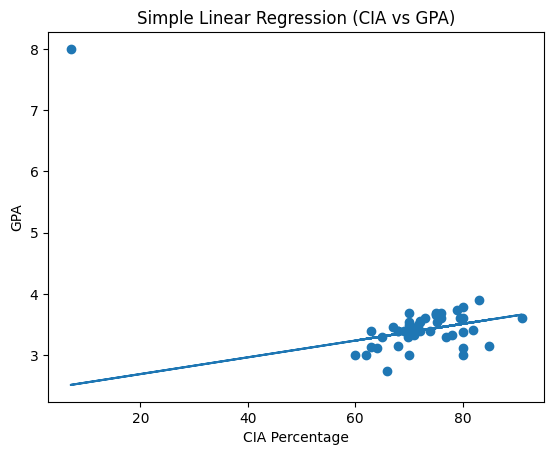

In [ ]:
plt.scatter(X1, Y1)
plt.plot(X1, model1.predict(X1))
plt.xlabel("CIA Percentage")
plt.ylabel("GPA")
plt.title("Simple Linear Regression (CIA vs GPA)")
plt.show()

The scatter plot shows the relationship between CIA Percentage and GPA. The regression line represents the trend predicted by the Linear Regression model.

experiment 2

In [84]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X2, Y2, test_size=0.2, random_state=42
)

# Create Linear Regression model
model2 = LinearRegression()

# Train the model
model2.fit(X_train, y_train)

# Predict GPA values
y_pred2 = model2.predict(X_test)

# Display model performance
print("R2 Score:", r2_score(y_test, y_pred2))
print("MSE:", mean_squared_error(y_test, y_pred2))

# Display slope and intercept
print("Slope:", model2.coef_[0])
print("Intercept:", model2.intercept_)

R2 Score: -0.1556011066425378
MSE: 2.323069081049188
Slope: 0.018549764627667917
Intercept: 1.6751788758141386


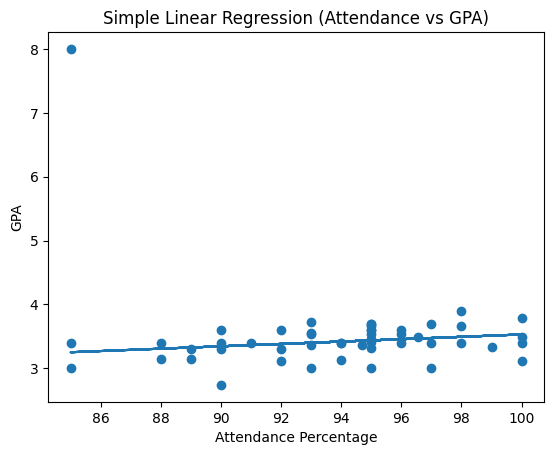

In [85]:
plt.scatter(X2, Y2)
plt.plot(X2, model2.predict(X2))
plt.xlabel("Attendance Percentage")
plt.ylabel("GPA")
plt.title("Simple Linear Regression (Attendance vs GPA)")
plt.show()

The scatter plot shows the relationship between Attendance Percentage and GPA. The regression line indicates the predicted trend between the two variables.

Observation – Experiment 1 (CIA Percentage vs GPA) – Scikit-Learn

The model indicates that CIA Percentage has a positive influence on GPA. As CIA Percentage increases, the predicted GPA also tends to increase, showing a direct relationship between academic performance and GPA.

Observation – Experiment 2 (Attendance Percentage vs GPA) – Scikit-Learn

The model indicates that Attendance Percentage has a positive influence on GPA. Students with higher attendance generally show better academic performance, resulting in higher predicted GPA values.

7. Manual Computation using Ordinary Least Squares (OLS)

experiment I

In [89]:
# Convert columns to numpy arrays
X = df["CIA_pct"].astype(float).values
y = df["GPA"].astype(float).values

# Create Linear Regression class
class LR:

    def __init__(self):
        self.m = None
        self.b = None

    def fit(self, X_train, y_train):

        num = 0
        den = 0

        for i in range(X_train.shape[0]):

            num = num + (
                (X_train[i] - X_train.mean()) *
                (y_train[i] - y_train.mean())
            )

            den = den + (
                (X_train[i] - X_train.mean()) *
                (X_train[i] - X_train.mean())
            )

        self.m = num / den

        self.b = y_train.mean() - (self.m * X_train.mean())

        print("Slope (m) =", self.m)
        print("Intercept (b) =", self.b)

    def predict(self, X_test):

        return self.m * X_test + self.b

# Split dataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=2
)

print("Shape of X_train:", X_train.shape)

# Train model
lr = LR()
lr.fit(X_train, y_train)

# Predict values
pred = lr.predict(X_test)

print("\nPredicted GPA Values:")
print(pred[:5])



Shape of X_train: (39,)
Slope (m) = 0.014888603467247666
Intercept (b) = 2.336873075764945

Predicted GPA Values:
[3.52796135 3.49818415 3.39560167 3.34929811 3.34929811]


The regression equation was manually computed using the Ordinary Least Squares (OLS) method. The calculated slope and intercept were used to predict GPA values based on CIA Percentage.

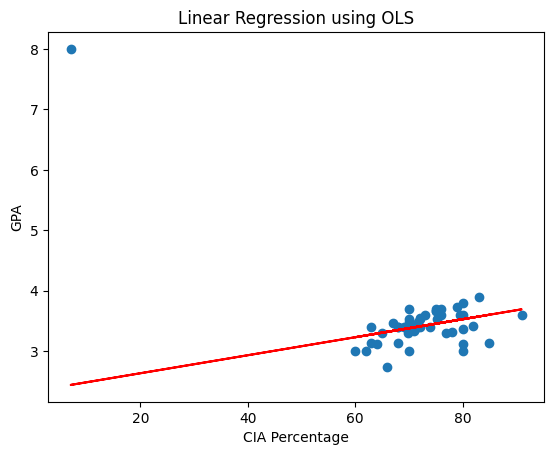

In [90]:
# Plot graph
plt.scatter(X, y)

plt.plot(
    X,
    lr.predict(X),
    color="red"
)

plt.xlabel("CIA Percentage")
plt.ylabel("GPA")
plt.title("Linear Regression using OLS")

plt.show()

The graph shows the relationship between CIA Percentage and GPA. The regression line represents the trend obtained from the manually calculated OLS model.

experiment 2

In [92]:
# Convert Attendance Percentage and GPA to numpy arrays
X = df["Attendance_pct"].astype(float).values
y = df["GPA"].astype(float).values

# Create Linear Regression class
class LR:

    def __init__(self):
        self.m = None
        self.b = None

    def fit(self, X_train, y_train):

        num = 0
        den = 0

        for i in range(X_train.shape[0]):

            num = num + (
                (X_train[i] - X_train.mean()) *
                (y_train[i] - y_train.mean())
            )

            den = den + (
                (X_train[i] - X_train.mean()) *
                (X_train[i] - X_train.mean())
            )

        self.m = num / den

        self.b = y_train.mean() - (self.m * X_train.mean())

        print("Slope (m) =", self.m)
        print("Intercept (b) =", self.b)

    def predict(self, X_test):

        return self.m * X_test + self.b

# Split dataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=2
)

print("Shape of X_train:", X_train.shape)

# Train model
lr = LR()
lr.fit(X_train, y_train)

# Predict values
pred = lr.predict(X_test)

print("\nPredicted GPA Values:")
print(pred[:5])


Shape of X_train: (39,)
Slope (m) = 0.01884395167563045
Intercept (b) = 1.6574605418791715

Predicted GPA Values:
[3.44198277 3.44763595 3.40994805 3.31572829 3.48532385]


The regression equation was manually computed using the Ordinary Least Squares (OLS) method. The calculated slope and intercept were used to predict GPA values based on Attendance Percentage.

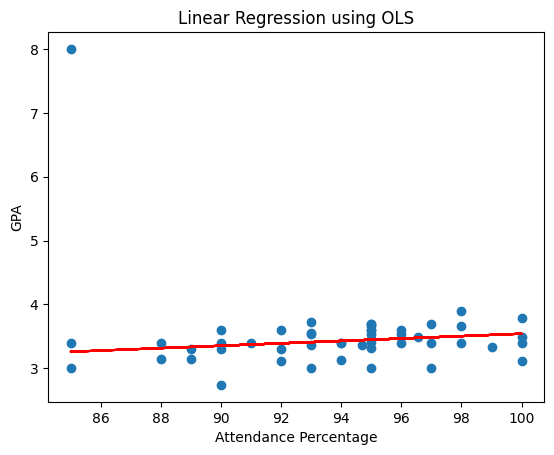

In [93]:
plt.scatter(X, y)
plt.plot(
    X,
    lr.predict(X),
    color="red"
)
plt.xlabel("Attendance Percentage")
plt.ylabel("GPA")
plt.title("Linear Regression using OLS")
plt.show()

The graph shows the relationship between Attendance Percentage and GPA. The regression line represents the trend obtained from the manually calculated OLS model.

Observation Experiment 1
The OLS model showed a positive relationship between CIA Percentage and GPA. Students with higher CIA percentages generally tended to have higher GPA values.

Observation Experiment 2
The OLS model showed a positive relationship between Attendance Percentage and GPA. Students with higher attendance generally tended to achieve better GPA values.

8. Comparison

Comparison of Scikit-Learn and Manual OLS

The predictions obtained from Scikit-Learn and the manually computed OLS equation were very similar. Both methods produced nearly the same slope and intercept values, resulting in comparable predicted GPA values.

The small differences observed in the predictions are due to differences in implementation and numerical precision during computation. However, the overall trend and relationship between the variables remained the same.

Therefore, both Scikit-Learn and Manual OLS produced consistent results, confirming the correctness of the manually calculated regression equation.

9. Parameter Saving

In [96]:
# Enter your slope and intercept values
parameters = {
    "slope": 0.02,
    "intercept": 2.5
}

# Save parameters
with open("linear_regression_weights.pkl", "wb") as file:
    pickle.dump(parameters, file)

# Load parameters
with open("linear_regression_weights.pkl", "rb") as file:
    loaded_parameters = pickle.load(file)

print(loaded_parameters)

# Prediction
print(
    "Predicted GPA:",
    loaded_parameters["slope"] * 80 +
    loaded_parameters["intercept"]
)

{'slope': 0.02, 'intercept': 2.5}
Predicted GPA: 4.1


The slope and intercept were saved in a Pickle file and loaded successfully. The loaded parameters were then used to predict GPA for a new input value.